# LangGraph functionality primer — before Day 1 AM

This offline notebook introduces the LangGraph APIs required by the main Day 1 demonstrations:

- `StateGraph`, typed state, nodes, and edges
- conditional routing
- `invoke()` and `stream()`
- `MessagesState` and `ToolNode`
- graph visualization
- `InMemorySaver`, `thread_id`, and state inspection
- pause, update, and resume for human-in-the-loop flows
- `recursion_limit` for bounded execution

The examples use small in-code records and do not call a model provider.

<img src="langgraph_fundamentals.png" width="900" alt="LangGraph agentic AI fundamentals: graph orchestration, node types, message types, and session control APIs">

In [1]:
print()

In [2]:
from typing import Literal, TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
from langchain_core.tools import tool

# Small, authoritative in-code dataset used by the graph nodes.
CLAIMS = {
    "CLM-101": {"policy_id": "POL-101", "loss": "rear-end collision"},
    "CLM-202": {"policy_id": "POL-202", "loss": "flood damage"},
}
POLICIES = {
    "POL-101": {"active": True, "coverage": "collision"},
    "POL-202": {"active": False, "coverage": "home"},
}

print(f"Loaded {len(CLAIMS)} claims and {len(POLICIES)} policies")

d:\Ambilio\EXL-CampusHire\Week2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 2 claims and 2 policies


## 1. Build a graph with typed state

`StateGraph` is the graph builder. Each node receives the current state and returns only the fields it changes.

- `add_node()` registers node functions.
- `add_edge()` creates fixed transitions.
- `add_conditional_edges()` chooses the next node from state.
- `START` and `END` mark graph boundaries.
- `compile()` creates the runnable graph.

In [3]:
class TriageState(TypedDict):
    """State shared by the nodes in the triage graph."""

    claim_id: str
    evidence: dict
    route: str
    trace: list[str]


def lookup(state: TriageState) -> dict:
    """Load the in-code claim and its policy."""
    claim = CLAIMS.get(state["claim_id"])
    policy = POLICIES.get(claim["policy_id"]) if claim else None
    return {
        "evidence": {"claim": claim, "policy": policy},
        "trace": [*state["trace"], "lookup"],
    }


def route_after_lookup(state: TriageState) -> Literal["route", "not_found"]:
    """Select a node from the evidence currently in state."""
    return "route" if state["evidence"]["claim"] else "not_found"


def route_claim(state: TriageState) -> dict:
    """Set a route from the supplied policy record."""
    policy = state["evidence"]["policy"]
    route = "coverage_review" if policy["active"] else "manual_review"
    return {"route": route, "trace": [*state["trace"], "route"]}


def not_found(state: TriageState) -> dict:
    """Return an explicit route when the claim does not exist."""
    return {"route": "not_found", "trace": [*state["trace"], "not_found"]}


builder = StateGraph(TriageState)
builder.add_node("lookup", lookup)
builder.add_node("route", route_claim)
builder.add_node("not_found", not_found)
builder.add_edge(START, "lookup")
builder.add_conditional_edges("lookup", route_after_lookup)
builder.add_edge("route", END)
builder.add_edge("not_found", END)
triage_graph = builder.compile()

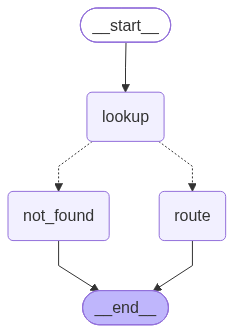

In [4]:
from IPython.display import Image, display

# Render the compiled StateGraph as a diagram.
display(Image(triage_graph.get_graph().draw_mermaid_png()))

In [6]:
def initial_state(claim_id: str) -> TriageState:
    """Create the initial state passed to invoke()."""
    return {"claim_id": claim_id, "evidence": {}, "route": "", "trace": []}


found = triage_graph.invoke(initial_state("CLM-101"))
missing = triage_graph.invoke(initial_state("CLM-999"))

print("Found:", found["route"], found["trace"])
print("Missing:", missing["route"], missing["trace"])

Found: coverage_review ['lookup', 'route']
Missing: not_found ['lookup', 'not_found']


## 2. Use message state and ToolNode

`MessagesState` provides a message list with the correct reducer. `ToolNode` executes tool calls found in an `AIMessage` and appends the resulting `ToolMessage`.

The planner below is deterministic only to keep this primer offline. In the main demonstrations, a chat model produces the `AIMessage` and its tool calls.

In [29]:
@tool
def claim_lookup(claim_id: str) -> dict:
    """Return one supplied claim, or an explicit not-found result."""
    return CLAIMS.get(claim_id, {"found": False, "claim_id": claim_id})


def planner(state: MessagesState) -> dict:
    """Create one tool call, then finish after ToolNode returns its result."""
    last = state["messages"][-1]
    if isinstance(last, ToolMessage):
        return {"messages": [AIMessage(content=f"Tool result: {last.content}")]}
    claim_id = last.content.split()[-1]
    return {
        "messages": [AIMessage(
            content="",
            tool_calls=[{
                "name": "claim_lookup",
                "args": {"claim_id": claim_id},
                "id": "lookup-1",
                "type": "tool_call",
            }],
        )]
    }


def continue_or_end(state: MessagesState) -> Literal["tools", "__end__"]:
    """Send tool calls to ToolNode and completed responses to END."""
    last = state["messages"][-1]
    return "tools" if isinstance(last, AIMessage) and last.tool_calls else END


loop_builder = StateGraph(MessagesState)
loop_builder.add_node("planner", planner)
loop_builder.add_node("tools", ToolNode([claim_lookup]))
loop_builder.add_edge(START, "planner")
loop_builder.add_conditional_edges("planner", continue_or_end)
loop_builder.add_edge("tools", "planner")
agent_loop = loop_builder.compile()

In [30]:
loop_result = agent_loop.invoke(
    {"messages": [HumanMessage(content="Look up CLM-101")]},
    config={"recursion_limit": 6},
)

print(">"*20,"Messages:")
for m in loop_result.get("messages"):
    print("\n$$",type(m).__name__,"$$:")
    print(m)
print("<"*20, "\n")

for message in loop_result["messages"]:
    print(type(message).__name__, message.content or getattr(message, "tool_calls", ""))

>>>>>>>>>>>>>>>>>>>> Messages:

$$ HumanMessage $$:
content='Look up CLM-101' additional_kwargs={} response_metadata={} id='0cc82976-8a57-4240-9840-c2e7fffe26ee'

$$ AIMessage $$:
content='' additional_kwargs={} response_metadata={} id='eca5da0a-8f15-43bd-8598-82a41c214a83' tool_calls=[{'name': 'claim_lookup', 'args': {'claim_id': 'CLM-101'}, 'id': 'lookup-1', 'type': 'tool_call'}] invalid_tool_calls=[]

$$ ToolMessage $$:
content='{"policy_id": "POL-101", "loss": "rear-end collision"}' name='claim_lookup' id='8a5a1961-8b83-4ac6-93af-8add461c500a' tool_call_id='lookup-1'

$$ AIMessage $$:
content='Tool result: {"policy_id": "POL-101", "loss": "rear-end collision"}' additional_kwargs={} response_metadata={} id='165a90ad-c5ab-45d1-8046-f4912915d7f6' tool_calls=[] invalid_tool_calls=[]
<<<<<<<<<<<<<<<<<<<< 

HumanMessage Look up CLM-101
AIMessage [{'name': 'claim_lookup', 'args': {'claim_id': 'CLM-101'}, 'id': 'lookup-1', 'type': 'tool_call'}]
ToolMessage {"policy_id": "POL-101", "loss": 

In [31]:
loop_result = agent_loop.invoke(
    {"messages": [HumanMessage(content="Look up CLM-102")]},
    config={"recursion_limit": 6},
)

print(">"*20,"Messages:")
for m in loop_result.get("messages"):
    print("\n$$",type(m).__name__,"$$:")
    print(m)
print("<"*20, "\n")

for message in loop_result["messages"]:
    print(type(message).__name__, message.content or getattr(message, "tool_calls", ""))

>>>>>>>>>>>>>>>>>>>> Messages:

$$ HumanMessage $$:
content='Look up CLM-102' additional_kwargs={} response_metadata={} id='62c433d5-c509-464b-938a-0c255b9fb3f6'

$$ AIMessage $$:
content='' additional_kwargs={} response_metadata={} id='ef8b234a-9976-44ce-bcd7-43fbc08aeace' tool_calls=[{'name': 'claim_lookup', 'args': {'claim_id': 'CLM-102'}, 'id': 'lookup-1', 'type': 'tool_call'}] invalid_tool_calls=[]

$$ ToolMessage $$:
content='{"found": false, "claim_id": "CLM-102"}' name='claim_lookup' id='d306b80d-c1a6-4c18-ae90-84668bbd8dd5' tool_call_id='lookup-1'

$$ AIMessage $$:
content='Tool result: {"found": false, "claim_id": "CLM-102"}' additional_kwargs={} response_metadata={} id='5aa97b4e-54ad-40a7-895e-f59b4d5ed0ba' tool_calls=[] invalid_tool_calls=[]
<<<<<<<<<<<<<<<<<<<< 

HumanMessage Look up CLM-102
AIMessage [{'name': 'claim_lookup', 'args': {'claim_id': 'CLM-102'}, 'id': 'lookup-1', 'type': 'tool_call'}]
ToolMessage {"found": false, "claim_id": "CLM-102"}
AIMessage Tool result: 

## 3. Inspect tool schemas and stream graph updates

The tool decorator creates the argument schema consumed by `ToolNode`. LangGraph can also stream node updates instead of returning only the final state.

`stream_mode="updates"` yields each node's partial state update. This is useful for logs, progress displays, and debugging.

In [32]:
print("Tool input schema:")
print(claim_lookup.args_schema.model_json_schema())

print("\nNode updates:")
for update in triage_graph.stream(
    initial_state("CLM-202"),
    stream_mode="updates",
):
    print(update)

Tool input schema:
{'description': 'Return one supplied claim, or an explicit not-found result.', 'properties': {'claim_id': {'title': 'Claim Id', 'type': 'string'}}, 'required': ['claim_id'], 'title': 'claim_lookup', 'type': 'object'}

Node updates:
{'lookup': {'evidence': {'claim': {'policy_id': 'POL-202', 'loss': 'flood damage'}, 'policy': {'active': False, 'coverage': 'home'}}, 'trace': ['lookup']}}
{'route': {'route': 'manual_review', 'trace': ['lookup', 'route']}}


## 4. Compare runs with and without a checkpointer

`compile()` without a checkpointer returns a final state and then discards it. You can read the `invoke()` result, but you cannot ask the graph for that thread's saved state later.

`compile(checkpointer=...)` stores snapshots keyed by `thread_id`. After `invoke()`, `get_state(config)` returns the saved values and any nodes still waiting to run.

`InMemorySaver` is enough for this notebook demo; it does not survive a process restart.

In [34]:
# Example A — no checkpointer: invoke returns state, but nothing is saved for later.
plain_graph = builder.compile()
plain_result = plain_graph.invoke(
    initial_state("CLM-101"),
    config={"recursion_limit": 6},
)

print("Without checkpointer — invoke() result:")
print("  route:", plain_result["route"])
print("  trace:", plain_result["trace"])

try:
    plain_graph.get_state({"configurable": {"thread_id": "claim-thread-1"}})
except ValueError as error:
    print("Without checkpointer — get_state() fails:")
    print(" ", error)

Without checkpointer — invoke() result:
  route: coverage_review
  trace: ['lookup', 'route']
Without checkpointer — get_state() fails:
  No checkpointer set


In [38]:
# Example B — with checkpointer: invoke still returns state, and get_state() can reload it.
checkpointer = InMemorySaver()
checkpointed_graph = builder.compile(checkpointer=checkpointer)
thread_config = {
    "configurable": {"thread_id": "claim-thread-1"},
    "recursion_limit": 6,
}

checkpointed_result = checkpointed_graph.invoke(
    initial_state("CLM-101"),
    config=thread_config,
)
snapshot = checkpointed_graph.get_state(thread_config)

print("$$ checkpointed_result:", checkpointed_result)
print("$$ snapshot:", snapshot)

print("With checkpointer — invoke() result:")
print("  route:", checkpointed_result["route"])
print("  trace:", checkpointed_result["trace"])

print("With checkpointer — get_state() after invoke:")
print("  saved route:", snapshot.values["route"])
print("  saved trace:", snapshot.values["trace"])
print("  waiting nodes:", snapshot.next)
print("  same values as invoke():", snapshot.values["route"] == checkpointed_result["route"])

$$ checkpointed_result: {'claim_id': 'CLM-101', 'evidence': {'claim': {'policy_id': 'POL-101', 'loss': 'rear-end collision'}, 'policy': {'active': True, 'coverage': 'collision'}}, 'route': 'coverage_review', 'trace': ['lookup', 'route']}
$$ snapshot: StateSnapshot(values={'claim_id': 'CLM-101', 'evidence': {'claim': {'policy_id': 'POL-101', 'loss': 'rear-end collision'}, 'policy': {'active': True, 'coverage': 'collision'}}, 'route': 'coverage_review', 'trace': ['lookup', 'route']}, next=(), config={'configurable': {'thread_id': 'claim-thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f183b90-127e-6c5d-8002-aadfb4f7b082'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-19T21:30:03.677794+00:00', parent_config={'configurable': {'thread_id': 'claim-thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f183b90-127c-6870-8001-9defdaad680b'}}, tasks=(), interrupts=())
With checkpointer — invoke() result:
  route: coverage_review
  trace: ['lookup', 'route']
With ch

## 5. Pause, update, and resume

A compiled graph can pause before a node with `interrupt_before`. The application can inspect the checkpoint, update state, and continue with `invoke(None, config=...)`.

This is the basic LangGraph functionality used for human approval workflows.

In the next cell, the graph pauses before `apply`. You act as the human operator and type an approval decision:

| Type this | Result |
| --- | --- |
| `y`, `yes`, or `approve` | `approved` |
| `n`, `no`, or `reject` | `rejected` |

Anything else is treated as a rejection.


In [43]:
class ApprovalState(TypedDict):
    """State for a graph that pauses before applying approval."""
    request_id: str
    approved: bool | None
    result: str


def prepare_request(state: ApprovalState) -> dict:
    """Prepare the request before the graph pauses."""
    return {"result": "waiting_for_approval"}


def apply_decision(state: ApprovalState) -> dict:
    """Apply the approval value supplied during resume."""
    result = "approved" if state["approved"] else "rejected"
    return {"result": result}


def parse_approval(raw: str) -> bool:
    """Map operator text to a boolean approval decision."""
    answer = raw.strip().lower()
    return answer in {"y", "yes", "approve"}


approval_builder = StateGraph(ApprovalState)
approval_builder.add_node("prepare", prepare_request)
approval_builder.add_node("apply", apply_decision)
approval_builder.add_edge(START, "prepare")
approval_builder.add_edge("prepare", "apply")
approval_builder.add_edge("apply", END)

approval_graph = approval_builder.compile(
    checkpointer=InMemorySaver(),
    interrupt_before=["apply"],
)
approval_config = {"configurable": {"thread_id": "approval-thread-1"}}

approval_graph.invoke(
    {"request_id": "REQ-1", "approved": None, "result": ""},
    config=approval_config,
)
print("Paused before:", approval_graph.get_state(approval_config).next)
print("Request waiting for human approval:", approval_graph.get_state(approval_config).values)

# Simulate the human operator. Try: y / yes / approve  OR  n / no / reject
decision = input("Approve this request? [y/n/approve/reject]: ")
approved = parse_approval(decision)
print(f"Operator entered {decision!r} -> approved={approved}")

approval_graph.update_state(approval_config, {"approved": approved})
approval_graph.invoke(None, config=approval_config)
print("Final result:", approval_graph.get_state(approval_config).values["result"])

Paused before: ('apply',)
Request waiting for human approval: {'request_id': 'REQ-1', 'approved': None, 'result': 'waiting_for_approval'}
Operator entered 'yes' -> approved=True
Final result: approved


## 6. Inspect and bound execution

LangGraph can render the compiled graph as an image. Both variations below use the **same** `agent_loop` graph (with `planner` and `tools`), start at `__start__`, and share one initial message state.

The only difference is `recursion_limit` — the step budget after `START`:

| Variation | Same input | `recursion_limit` | What to notice |
| --- | --- | --- | --- |
| A | `Look up CLM-101` | `2` | stops early; cannot finish `planner → tools → planner` |
| B | `Look up CLM-101` | `6` | completes from `START` through the full planner/tool loop |

Each step prints the **state before** and **state after** the node runs (`stream_mode=["updates", "values"]`).


Compiled agent_loop graph with planner (both variations start at START)


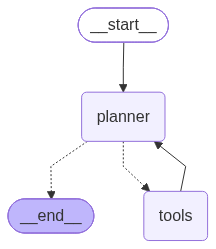

Shared initial state: {'messages': [HumanMessage(content='Look up CLM-101', additional_kwargs={}, response_metadata={})]}


In [52]:
from IPython.display import Image, display
from langgraph.errors import GraphRecursionError

print("Compiled agent_loop graph with planner (both variations start at START)")
display(Image(agent_loop.get_graph().draw_mermaid_png()))

# Identical payload for both variations
shared_state = {"messages": [HumanMessage(content="Look up CLM-101")]}
print("Shared initial state:", shared_state)


def summarize_messages(state: dict) -> list[str]:
    """Compact view of message roles/content/tool calls for teaching."""
    lines: list[str] = []
    for message in state.get("messages", []):
        kind = type(message).__name__
        detail = message.content or getattr(message, "tool_calls", "")
        lines.append(f"{kind}: {detail}")
    return lines


def run_and_count_steps(
    graph,
    payload,
    *,
    label: str,
    recursion_limit: int,
) -> dict:
    """Stream one run from START and print state before/after each node."""
    steps: list = []
    status = "completed"
    before = payload
    pending_node: str | None = None

    print(f"\n{label}")
    print(f"  recursion_limit={recursion_limit}")
    print("  initial state (before any node):")
    for line in summarize_messages(before):
        print(f"    {line}")

    try:
        for mode, chunk in graph.stream(
            payload,
            config={"recursion_limit": recursion_limit},
            stream_mode=["updates", "values"],
        ):
            if mode == "updates":
                pending_node = next(iter(chunk))
                continue

            # mode == "values": full state after the node that just ran
            after = chunk
            steps.append({"node": pending_node, "before": before, "after": after})
            print(f"\n  step {len(steps)}: {pending_node}")
            print("    BEFORE:")
            for line in summarize_messages(before):
                print(f"      {line}")
            print("    AFTER:")
            for line in summarize_messages(after):
                print(f"      {line}")
            before = after
            pending_node = None
    except GraphRecursionError as error:
        status = "recursion_limit_hit"
        print(f"\n  stopped: {type(error).__name__}: {error}")

    print(f"\n{label} -> status={status}, steps={len(steps)}")
    return {"status": status, "steps": len(steps), "trace": steps}


In [53]:
variation_a = run_and_count_steps(
    agent_loop,
    shared_state,
    label="Variation A - tight bound",
    recursion_limit=2,
)
print(f"Variation A: status={variation_a['status']}, steps={variation_a['steps']}")


Variation A - tight bound
  recursion_limit=2
  initial state (before any node):
    HumanMessage: Look up CLM-101

  step 1: None
    BEFORE:
      HumanMessage: Look up CLM-101
    AFTER:
      HumanMessage: Look up CLM-101

  step 2: planner
    BEFORE:
      HumanMessage: Look up CLM-101
    AFTER:
      HumanMessage: Look up CLM-101
      AIMessage: [{'name': 'claim_lookup', 'args': {'claim_id': 'CLM-101'}, 'id': 'lookup-1', 'type': 'tool_call'}]

  step 3: tools
    BEFORE:
      HumanMessage: Look up CLM-101
      AIMessage: [{'name': 'claim_lookup', 'args': {'claim_id': 'CLM-101'}, 'id': 'lookup-1', 'type': 'tool_call'}]
    AFTER:
      HumanMessage: Look up CLM-101
      AIMessage: [{'name': 'claim_lookup', 'args': {'claim_id': 'CLM-101'}, 'id': 'lookup-1', 'type': 'tool_call'}]
      ToolMessage: {"policy_id": "POL-101", "loss": "rear-end collision"}

  stopped: GraphRecursionError: Recursion limit of 2 reached without hitting a stop condition. You can increase the limit by

In [ ]:
variation_b = run_and_count_steps(
    agent_loop,
    shared_state,
    label="Variation B - enough budget",
    recursion_limit=6,
)

print(f"Variation B: status={variation_b['status']}, steps={variation_b['steps']}")


Variation B - enough budget
  recursion_limit=6
  initial state (before any node):
    HumanMessage: Look up CLM-101

  step 1: None
    BEFORE:
      HumanMessage: Look up CLM-101
    AFTER:
      HumanMessage: Look up CLM-101

  step 2: planner
    BEFORE:
      HumanMessage: Look up CLM-101
    AFTER:
      HumanMessage: Look up CLM-101
      AIMessage: [{'name': 'claim_lookup', 'args': {'claim_id': 'CLM-101'}, 'id': 'lookup-1', 'type': 'tool_call'}]

  step 3: tools
    BEFORE:
      HumanMessage: Look up CLM-101
      AIMessage: [{'name': 'claim_lookup', 'args': {'claim_id': 'CLM-101'}, 'id': 'lookup-1', 'type': 'tool_call'}]
    AFTER:
      HumanMessage: Look up CLM-101
      AIMessage: [{'name': 'claim_lookup', 'args': {'claim_id': 'CLM-101'}, 'id': 'lookup-1', 'type': 'tool_call'}]
      ToolMessage: {"policy_id": "POL-101", "loss": "rear-end collision"}

  step 4: planner
    BEFORE:
      HumanMessage: Look up CLM-101
      AIMessage: [{'name': 'claim_lookup', 'args': {'cla

: 

## Continue to the main AM demonstrations

This primer used the LangGraph functionality required for Day 1: graph construction, routing, invocation, streaming, tools, messages, checkpoints, state inspection, pause/resume, visualization, and recursion limits.

**Next:** open `../W2D1AM/_DEMONSTRATIONS.ipynb` to use the same APIs with genuine model calls and domain tools.